# County-Level Alignment Between Presidential and Gubernatorial Voting in 2020

**DATASCI 151 Final Project**  
**Group Members:**

- Quinn Weisenfeld — 2709952
- Kai Itokazu — 2609975
- Nicole Rivkin — 2604507
- Jichao Liu — 2792168

---




## Guiding Question

> Across the states in this dataset with gubernatorial races, how closely did county-level gubernatorial results track presidential results, and was greater divergence associated with higher presidential third-party vote share?


## Introduction

In the US, presidential elections are held every four years, but on the same day voters typically also cast ballots for several other offices, like the office of governor. A natural question for understanding American voting behaviour is whether voters support candidates from the same political party up and down the ballot, or whether they "split their ticket" by choosing, for instance, a Democratic candidate for president and a Republican candidate for governor or the reverse. In 2020, Joe Biden (D) ran against incumbent Donald Trump (R) for president, and eleven states simultaneously held gubernatorial elections. Because US election results are reported at the county level (counties being the administrative subdivisions that make up each state),comparing presidential and gubernatorial outcomes county-by-county gives us a detailed view of how consistent voter behaviour was across these two offices, which in turn speaks to how "nationalized" state politics has become and where voters still distinguish between a party and its individual candidates.

Our project asked: across the eleven states that held both a presidential and a gubernatorial race in 2020, how closely did county-level gubernatorial results track presidential results, and was greater divergence between the two associated with a larger presidential third-party vote share? To answer this, we combined four tables from the 2020 US Election dataset (candidate-level and county-total files for both the presidential and gubernatorial races), restricted the analysis to the eleven overlapping states, recoded every candidate's party as Democratic, Republican, or Other, and computed comparable two-party Democratic vote shares for each office in every county. We then examined the correlation between the two shares, identified counties wherein the two offices produced different winners, and tested whether that divergence grew in counties with more third-party presidential voting. We found that county-level results for the two offices were strongly correlated overall, but a small number of states — most visibly Vermont, and to a lesser extent New Hampshire —- showed substantial ticket-splitting, while divergence tended to be modestly larger in counties with higher third-party presidential vote shares. The remainder of our project is as follows: Section 2 describes the source data; Sections 3–5 cover loading, cleaning, and merging the four tables into a single county-level analysis table, and the following sections compute descriptive statistics and the core analytic columns and present the main results. Section 9 discusses what we learned.


In [25]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)


## Data Overview

This project uses four tables from the 2020 US Election dataset. Two describe the presidential race: president_county_candidate.csv (32,177 rows) contains one row per candidate per county, listing the candidate's name, party, and vote total, while president_county.csv (4,633 rows) gives one row per county with the total ballots cast. The other two describe the 2020 gubernatorial races: governors_county_candidate.csv (5,145 rows) has one row per gubernatorial candidate per county, and governors_county.csv (1,025 rows) has one row per county with total ballots cast in the gubernatorial contest. The presidential files cover all fifty states plus Washington DC, while the gubernatorial files cover only the eleven states which held a governor's race in 2020. This is what ultimately bounds the scope of our analysis. Each row in the candidate files represents a single candidate's performance in a single county, and each row in the county-total files represents one county. One data-structure note worth flagging: in Vermont and New Hampshire, the dataset reports results at the town level rather than at the true county level, so the "county" row counts for those two states (246 and 237, respectively) are higher than their actual number of counties. We decided to keep the dataset's original naming structure and refer to these units as "counties" throughout, but this means Vermont and New Hampshire are disproportionately represented in our row-level statistics.

In [26]:
#load data

pres_cand = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")
pres_total = pd.read_csv("4-US_Election_2020/president_county.csv")
gov_cand = pd.read_csv("4-US_Election_2020/governors_county_candidate.csv")
gov_total = pd.read_csv("4-US_Election_2020/governors_county.csv")


#print for data viewing
for name, df in [('pres_cand', pres_cand), ('gov_cand', gov_cand), ('pres_total', pres_total), ('gov_total', gov_total)]:
    print(f'\n{name}')
    print('shape:', df.shape)
    print(df.head(3))

df_townExample = pres_cand.query("state == 'Vermont'")
df_townExample.head(3)



pres_cand
shape: (32177, 6)
      state       county     candidate party  total_votes    won
0  Delaware  Kent County     Joe Biden   DEM        44552   True
1  Delaware  Kent County  Donald Trump   REP        41009  False
2  Delaware  Kent County  Jo Jorgensen   LIB         1044  False

gov_cand
shape: (5145, 6)
      state       county        candidate party  votes    won
0  Delaware  Kent County      John Carney   DEM  44352   True
1  Delaware  Kent County  Julianne Murray   REP  39332  False
2  Delaware  Kent County  Kathy DeMatteis   IPD   1115  False

pres_total
shape: (4633, 5)
      state             county  current_votes  total_votes  percent
0  Delaware        Kent County          87025        87025      100
1  Delaware  New Castle County         287633       287633      100
2  Delaware      Sussex County         129352       129352      100

gov_total
shape: (1025, 5)
      state             county  current_votes  total_votes  percent
0  Delaware        Kent County         

,state,county,candidate,party,total_votes,won
20951,Vermont,Jamaica,Joe Biden,DEM,406,True
20952,Vermont,Jamaica,Donald Trump,REP,149,False
20953,Vermont,Jamaica,Jo Jorgensen,LIB,6,False


## Data Loading and Initial Inspection


Because the presidential files cover every state while the gubernatorial files only cover states that held a governor's race in 2020, our first step is to restrict every table to the set of states appearing in both. That intersection yields eleven states -- Delaware, Indiana, Missouri, Montana, New Hampshire, North Carolina, North Dakota, Utah, Vermont, Washington, and West Virginia -- which together span 1,025 county-level units. After this restriction, the candidate-level presidential table shrinks from 32,177 rows to 9,238 rows, while the gubernatorial candidate table is unchanged, asit was already limited to these states. All further analysis focuses on these eleven overlapping states.

In [27]:
#find overlapping states between presidential and governor county files

pres_states = set(pres_total['state'].dropna().unique())
gov_states = set(gov_total['state'].dropna().unique())
overlap_states = sorted(pres_states.intersection(gov_states))

print('Number of overlapping states:', len(overlap_states))
print(overlap_states)


Number of overlapping states: 11
['Delaware', 'Indiana', 'Missouri', 'Montana', 'New Hampshire', 'North Carolina', 'North Dakota', 'Utah', 'Vermont', 'Washington', 'West Virginia']


In [28]:
#restrict all tables to overlapping states

pres_cand = pres_cand[pres_cand['state'].isin(overlap_states)].copy()
pres_total = pres_total[pres_total['state'].isin(overlap_states)].copy()
gov_cand = gov_cand[gov_cand['state'].isin(overlap_states)].copy()
gov_total = gov_total[gov_total['state'].isin(overlap_states)].copy()

print('Restricted presidential candidate rows:', pres_cand.shape)
print('Restricted governor candidate rows:', gov_cand.shape)


Restricted presidential candidate rows: (9238, 6)
Restricted governor candidate rows: (5145, 6)


## Data Cleaning and Preparation


Before merging, we standardize the four tables so equivalent fields have the same labels and formatting across files. The gubernatorial candidate file originally uses a votes column where the presidential file uses total_votes, so we rename the former to match. We also strip leading and trailing whitespace from every state and county string to prevent merges from silently dropping rows due to formatting inconsistencies. The most consequential cleaning step is recoding parties: the raw data contains nineteen party labels in the presidential file (DEM, REP, LIB, GRN, IND, WRI, CST, PSL, and a number of smaller, state-specific labels) and twelve in the gubernatorial file. Because our question is about alignment (or lack thereof) between the two major parties, we collapse every label into one of three groups (DEM, REP, or OTHER) using string matching on the party code. After recoding, each office's candidate table contains 1,025 DEM rows, 1,025 REP rows, and several thousand OTHER rows, giving us a clean party-group variable that is consistent across offices.

In [29]:
#printing for data viewing  
for name, df in [('pres_cand', pres_cand), ('gov_cand', gov_cand), ('pres_total', pres_total), ('gov_total', gov_total)]:
    print(f'\n{name} columns:')
    print(df.columns.tolist())



pres_cand columns:
['state', 'county', 'candidate', 'party', 'total_votes', 'won']

gov_cand columns:
['state', 'county', 'candidate', 'party', 'votes', 'won']

pres_total columns:
['state', 'county', 'current_votes', 'total_votes', 'percent']

gov_total columns:
['state', 'county', 'current_votes', 'total_votes', 'percent']


In [30]:
#standardize vote column names to "total_votes" 
gov_cand = gov_cand.rename(columns={'votes': 'total_votes'})
print(pres_cand.columns.tolist())
print(gov_cand.columns.tolist())

['state', 'county', 'candidate', 'party', 'total_votes', 'won']
['state', 'county', 'candidate', 'party', 'total_votes', 'won']


In [31]:
#standardize county/state strings to make sure no errors for merging

def clean_location_columns(df):
    df = df.copy()
    df['state'] = df['state'].astype(str).str.strip()
    df['county'] = df['county'].astype(str).str.strip()
    return df

pres_cand = clean_location_columns(pres_cand)
pres_total = clean_location_columns(pres_total)
gov_cand = clean_location_columns(gov_cand)
gov_total = clean_location_columns(gov_total)


In [32]:
#print for data viewing
print('President party labels:')
print(pres_cand['party'].value_counts(dropna=False).head(20))

print('\nGovernor party labels:')
print(gov_cand['party'].value_counts(dropna=False).head(20))


President party labels:
party
IND    1288
DEM    1025
LIB    1025
REP    1025
WRI     956
GRN     587
CST     490
PSL     314
SWP     285
ASP     246
APV     246
ALI     246
PRO     246
BMP     246
BFP     246
BAR     246
GOP     246
IAP     246
UNA      29
Name: count, dtype: int64

Governor party labels:
party
DEM    1025
REP    1025
IND     984
LIB     740
WRI     577
TM      246
UNA     246
GRN     115
CST     100
MNP      55
IAP      29
IPD       3
Name: count, dtype: int64


In [33]:
#recode parties into DEM/REP/OTHER

def recode_party(party_value):
    p = str(party_value).strip().upper()
    if 'DEM' in p:
        return 'DEM'
    elif 'REP' in p or 'GOP' in p: #assuming GOP label is for Republican candidates
        return 'REP'
    else:
        return 'OTHER'

pres_cand['party_group'] = pres_cand['party'].apply(recode_party)
gov_cand['party_group'] = gov_cand['party'].apply(recode_party)

print(pres_cand['party_group'].value_counts())
print(gov_cand['party_group'].value_counts())


party_group
OTHER    6942
REP      1271
DEM      1025
Name: count, dtype: int64
party_group
OTHER    3095
DEM      1025
REP      1025
Name: count, dtype: int64


## Merging and Construction of the Main Analysis Table



To compare the parties county-by-county, we first collapse each candidate table into a county-level summary using a helper function (build_county_summary). For each office, the function groups the candidate-level data by state, county, and party group, sums votes within each group, and pivots so that every county has one row with separate columns for Democratic, Republican, and "Other" votes. From these, it derives each party's two-party vote share, the Democratic margin, and an indicator for which major party won the county (ties are assigned to Republicans, which affects no rows in practice). We apply this function separately to the presidential and gubernatorial candidate tables, merge each resulting summary with its corresponding county-total file, and then inner-join the two office-level summaries on state and county to produce a single analysis table with 1,025 rows (one per county). Finally, we engineer four variables directly on this merged table: winner_mismatch (True when the presidential and gubernatorial winners belong to different parties), abs_dem_share_diff (the absolute difference between the two offices' Democratic two-party shares), dem_overperformance (the signed version of that difference; positive when the Democratic candidate did better for governor than for president), and turnout_gap (the difference between presidential and gubernatorial ballot counts in a county, which captures how many voters cast a ballot in one race but skipped the other). Because the two source files both contain a total_votes field that reports the same countywide total, we use the office-specific current_votes field from each file instead, renaming these to pres_office_votes and gov_office_votes before differencing them.

In [34]:
#summarize county-level results for a given office

def build_county_summary(candidate_df, office_name):
    
    #return one row per state-county with party vote totals, shares, winner, and margin.
    
    df = candidate_df.copy()

    grouped = (
        df.groupby(['state', 'county', 'party_group'])['total_votes'] #group if same state-county and party  
          .sum() #sum votes for same state-county and party
          .reset_index() #grouped columns back to regular columns 
    )

    wide = grouped.pivot_table(
        index=['state', 'county'],
        columns='party_group', #party becomes a column w/ votes as values
        values='total_votes',
        fill_value=0 #if no votes for a party in a county, fill with 0 ; otherwise nan
    ).reset_index()

#in case some are not present, add missing party columns with 0 votes
    for col in ['DEM', 'REP', 'OTHER']:
        if col not in wide.columns:
            wide[col] = 0

#new useful columns and renaming for merging and simpler analysis later
    wide[f'{office_name}_dem_votes'] = wide['DEM']
    wide[f'{office_name}_rep_votes'] = wide['REP']
    wide[f'{office_name}_other_votes'] = wide['OTHER']

    wide[f'{office_name}_two_party_total'] = wide[f'{office_name}_dem_votes'] + wide[f'{office_name}_rep_votes']
    wide[f'{office_name}_all_candidate_total'] = (
        wide[f'{office_name}_dem_votes'] +
        wide[f'{office_name}_rep_votes'] +
        wide[f'{office_name}_other_votes']
    )

    wide[f'{office_name}_dem_share_2party'] = wide[f'{office_name}_dem_votes'] / wide[f'{office_name}_two_party_total']
    wide[f'{office_name}_rep_share_2party'] = wide[f'{office_name}_rep_votes'] / wide[f'{office_name}_two_party_total']
    wide[f'{office_name}_other_share_all'] = wide[f'{office_name}_other_votes'] / wide[f'{office_name}_all_candidate_total']
    wide[f'{office_name}_dem_margin_2party'] = wide[f'{office_name}_dem_share_2party'] - wide[f'{office_name}_rep_share_2party'] #rep margin just negative of this

    wide[f'{office_name}_winner'] = np.where(
        wide[f'{office_name}_dem_votes'] > wide[f'{office_name}_rep_votes'], #assuming 3rd party votes don't affect winner for simplicity. sorry George Washington
        'DEM',                                                               #also ties go to republicans  
        'REP'
    )

    keep_cols = [
        'state', 'county',
        f'{office_name}_dem_votes',
        f'{office_name}_rep_votes',
        f'{office_name}_other_votes',
        f'{office_name}_two_party_total',
        f'{office_name}_all_candidate_total',
        f'{office_name}_dem_share_2party',
        f'{office_name}_rep_share_2party',
        f'{office_name}_other_share_all',
        f'{office_name}_dem_margin_2party',
        f'{office_name}_winner'
    ]

    return wide[keep_cols] #get rid of the original DEM/REP/OTHER columns since we have the new renamed ones now


In [35]:
#county summaries for president and governor

pres_summary = build_county_summary(pres_cand, 'pres')
gov_summary = build_county_summary(gov_cand, 'gov')

print(pres_summary.head())
print(gov_summary.head())


party_group     state             county  pres_dem_votes  pres_rep_votes  \
0            Delaware        Kent County         44552.0         41009.0   
1            Delaware  New Castle County        195034.0         88364.0   
2            Delaware      Sussex County         56682.0         71230.0   
3             Indiana       Adams County          3236.0         10686.0   
4             Indiana       Allen County         73189.0         92083.0   

party_group  pres_other_votes  pres_two_party_total  pres_all_candidate_total  \
0                      1464.0               85561.0                   87025.0   
1                      4235.0              283398.0                  287633.0   
2                      1440.0              127912.0                  129352.0   
3                       287.0               13922.0                   14209.0   
4                      3810.0              165272.0                  169082.0   

party_group  pres_dem_share_2party  pres_rep_share_2part

In [36]:
#merge in county total-vote files

pres_total_small = pres_total[['state', 'county', 'current_votes']].copy()
pres_total_small = pres_total_small.rename(columns={'current_votes': 'pres_office_votes'})

gov_total_small = gov_total[['state', 'county', 'current_votes']].copy()
gov_total_small = gov_total_small.rename(columns={'current_votes': 'gov_office_votes'})

pres_summary = pres_summary.merge(pres_total_small, on=['state', 'county'], how='left')
gov_summary = gov_summary.merge(gov_total_small, on=['state', 'county'], how='left')


In [37]:
#main merged analysis table


analysis_df = pres_summary.merge(gov_summary, on=['state', 'county'], how='inner')

analysis_df['winner_mismatch'] = analysis_df['pres_winner'] != analysis_df['gov_winner']
analysis_df['abs_dem_share_diff'] = (
    analysis_df['pres_dem_share_2party'] - analysis_df['gov_dem_share_2party']
).abs()
analysis_df['dem_overperformance'] = (
    analysis_df['gov_dem_share_2party'] - analysis_df['pres_dem_share_2party']
)

analysis_df['turnout_gap'] = analysis_df['pres_office_votes'] - analysis_df['gov_office_votes']

analysis_df.head()


,state,county,pres_dem_votes,pres_rep_votes,pres_other_votes,pres_two_party_total,pres_all_candidate_total,pres_dem_share_2party,pres_rep_share_2party,pres_other_share_all,pres_dem_margin_2party,pres_winner,pres_office_votes,gov_dem_votes,gov_rep_votes,gov_other_votes,gov_two_party_total,gov_all_candidate_total,gov_dem_share_2party,gov_rep_share_2party,gov_other_share_all,gov_dem_margin_2party,gov_winner,gov_office_votes,winner_mismatch,abs_dem_share_diff,dem_overperformance,turnout_gap
0,Delaware,Kent County,44552.0,41009.0,1464.0,85561.0,87025.0,0.520705,0.479295,0.016823,0.041409,DEM,87025,44352.0,39332.0,1731.0,83684.0,85415.0,0.529994,0.470006,0.020266,0.059988,DEM,85415,False,0.009289,0.009289,1610
1,Delaware,New Castle County,195034.0,88364.0,4235.0,283398.0,287633.0,0.688198,0.311802,0.014724,0.376396,DEM,287633,191678.0,82545.0,5816.0,274223.0,280039.0,0.698986,0.301014,0.020769,0.397972,DEM,280039,False,0.010788,0.010788,7594
2,Delaware,Sussex County,56682.0,71230.0,1440.0,127912.0,129352.0,0.443133,0.556867,0.011132,-0.113734,REP,129352,56873.0,68435.0,1873.0,125308.0,127181.0,0.453866,0.546134,0.014727,-0.092269,REP,127181,False,0.010733,0.010733,2171
3,Indiana,Adams County,3236.0,10686.0,287.0,13922.0,14209.0,0.232438,0.767562,0.020198,-0.535124,REP,14209,2143.0,9441.0,2570.0,11584.0,14154.0,0.184997,0.815003,0.181574,-0.630007,REP,14154,False,0.047441,-0.047441,55
4,Indiana,Allen County,73189.0,92083.0,3810.0,165272.0,169082.0,0.442840,0.557160,0.022533,-0.114321,REP,169082,53895.0,98406.0,16011.0,152301.0,168312.0,0.353872,0.646128,0.095127,-0.292257,REP,168312,False,0.088968,-0.088968,770


## Descriptive Statistics

Our analysis focuses on five columns of the merged table: pres_dem_share_2party and gov_dem_share_2party (the Democratic two-party vote share for each office), abs_dem_share_diff (how far apart those two shares are in a given county), pres_other_share_all (the share of presidential votes going to third-party candidates, which we'll use to test the third-party hypothesis), and turnout_gap (presidential ballots minus gubernatorial ballots in a county). Across the 1,025 counties, the mean presidential Democratic share is 0.43 while the mean gubernatorial Democratic share is only 0.30, indicating that, averaged across this particular set of states, Democratic gubernatorial candidates ran noticeably behind Joe Biden. The absolute difference between the two shares averages 0.14 per county, but with a standard deviation nearly as large (0.15) and a maximum of 0.80, suggesting the distribution is heavily skewed by a minority of high-divergence counties. Third-party presidential vote share averages about 2% per county and never exceeds 11%, so while third-party voting is numerically small, it still varies enough across counties to support a meaningful comparison. The turnout gap averages 173 ballots per county with a median of just 32, consistent with the usual down-ballot drop-off pattern, but the range is wide: the largest positive gap is 12,458 (a big county where many presidential voters skipped the governor race) and the largest negative gap is –1,235 (a county where more voters cast a gubernatorial than a presidential ballot, which is a contrast to the typical pattern).

In [38]:
#descriptive statistics table

desc_cols = [
    'pres_dem_share_2party',
    'gov_dem_share_2party',
    'abs_dem_share_diff',
    'pres_other_share_all',
    'turnout_gap'
]

desc_table = analysis_df[desc_cols].describe().round(3)
desc_table


,pres_dem_share_2party,gov_dem_share_2party,abs_dem_share_diff,pres_other_share_all,turnout_gap
count,1025.000,1025.000,1025.000,1025.000,1025.000
mean,0.430,0.299,0.144,0.021,173.423
std,0.189,0.123,0.146,0.010,713.478
min,0.051,0.000,0.000,0.000,-1235.000
25%,0.255,0.212,0.023,0.015,9.000
50%,0.430,0.271,0.068,0.020,32.000
75%,0.569,0.359,0.225,0.027,108.000
max,1.000,0.831,0.800,0.105,12458.000


## Results




### Result 1. How often did counties choose different parties for president and governor?


Across all eleven states, 29.6% of counties produced different major-party winners for the presidential and gubernatorial races. That figure is heavily concentrated in two states: Vermont, where 79.7% of towns (196 of 246) went to different parties across the two offices, and New Hampshire, where the mismatch rate is 40.9% (97 of 237). Every other state in the dataset has a mismatch rate below 5%--North Carolina at 4.0%, Montana at 3.6%, Utah at 3.4%, Washington at 2.6%, and Indiana at 2.2%, with Delaware, Missouri, North Dakota, and West Virginia producing no county-level mismatches at all. The pattern lines up with what actually happened at the state level: Vermont voted for Biden by a wide margin but re-elected Republican governor Phil Scott in a landslide, and New Hampshire voted for Biden while re-electing Republican governor Chris Sununu. In the other nine states, the same party generally won both contests, so county-level agreement is almost automatic.

In [39]:
#overall mismatch rate

overall_mismatch = analysis_df['winner_mismatch'].mean()
print('Overall county-level mismatch rate:', round(overall_mismatch, 3))

# State-level mismatch table
mismatch_by_state = (
    analysis_df.groupby('state')['winner_mismatch']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'mismatch_rate', 'sum': 'num_mismatch', 'count': 'num_counties'})
    .sort_values('mismatch_rate', ascending=False)
    .round(3)
)

mismatch_by_state


Overall county-level mismatch rate: 0.296


,mismatch_rate,num_mismatch,num_counties
state,,,
Vermont,0.797,196,246
New Hampshire,0.409,97,237
North Carolina,0.040,4,100
Montana,0.036,2,56
Utah,0.034,1,29
Washington,0.026,1,39
Indiana,0.022,2,92
Delaware,0.000,0,3
Missouri,0.000,0,115


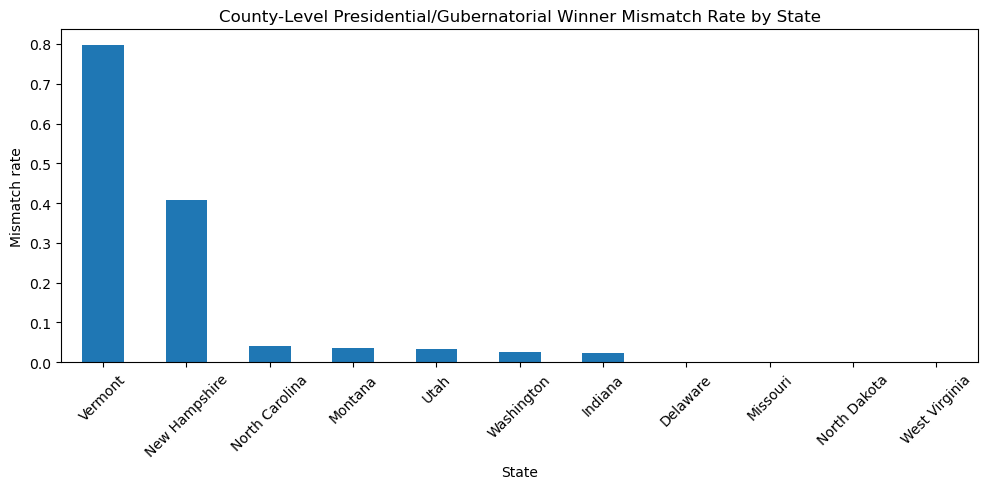

In [40]:
#plot: mismatch rate by state

mismatch_by_state['mismatch_rate'].plot(kind='bar', figsize=(10, 5))
plt.title('County-Level Presidential/Gubernatorial Winner Mismatch Rate by State')
plt.xlabel('State')
plt.ylabel('Mismatch rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Result 2. How closely do presidential and gubernatorial Democratic vote shares line up?


Plotting each county's presidential Democratic two-party share against its gubernatorial Democratic two-party share shows most points falling close to the 45-degree line, consistent with the picture from the mismatch analysis. When we quantify alignment state-by-state, using both the Pearson correlation between the two shares and the mean absolute difference between them, we find near-perfect alignment in most states: correlations above 0.97 and mean absolute differences under 0.05 in Delaware, Indiana, Missouri, Montana, North Carolina, North Dakota, Utah, and Washington. West Virginia sits slightly lower on correlation (0.946) but still has a very small mean absolute difference of 0.025. Vermont is a clear outlier, with a correlation of just 0.75 and a mean absolute difference of 0.36; New Hampshire sits between the two extremes at 0.88 and 0.18, respectively. So while the overall relationship between presidential and gubernatorial Democratic shares is strong, the state-level breakdown makes it clear that the aggregate correlation masks genuinely different patterns of voter behaviour in Vermont and, to a lesser extent, New Hampshire.

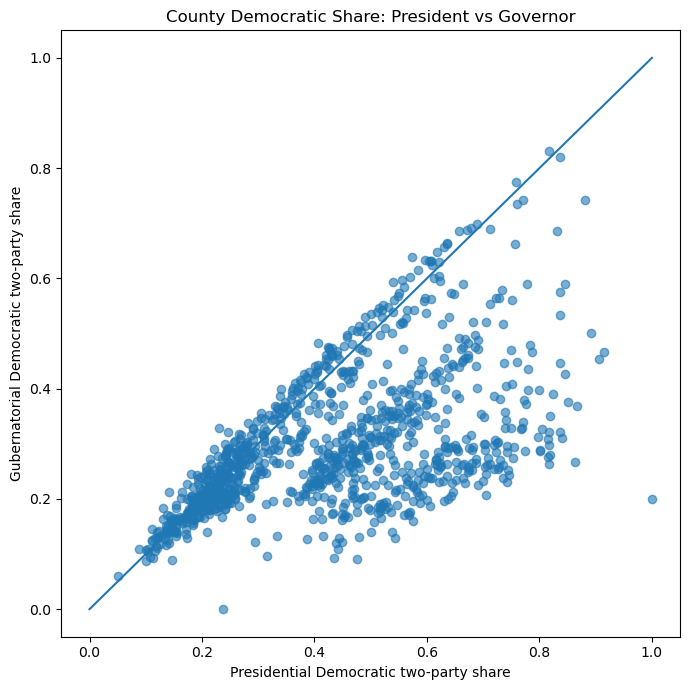

In [41]:
#scatterplot of presidential vs governor Democratic two-party share

plt.figure(figsize=(7, 7))
plt.scatter(analysis_df['pres_dem_share_2party'], analysis_df['gov_dem_share_2party'], alpha=0.6)
plt.plot([0, 1], [0, 1])
plt.title('County Democratic Share: President vs Governor')
plt.xlabel('Presidential Democratic two-party share')
plt.ylabel('Gubernatorial Democratic two-party share')
plt.tight_layout()
plt.show()


In [42]:
#state-level alignment summary

state_alignment = []

for state_name, subdf in analysis_df.groupby('state'):
    corr_val = subdf['pres_dem_share_2party'].corr(subdf['gov_dem_share_2party'])
    mad_val = subdf['abs_dem_share_diff'].mean()
    state_alignment.append({
        'state': state_name,
        'correlation': corr_val,
        'mean_abs_diff': mad_val,
        'n_counties': len(subdf)
    })

state_alignment = pd.DataFrame(state_alignment).sort_values('mean_abs_diff', ascending=False)
state_alignment.round(3)


,state,correlation,mean_abs_diff,n_counties
8,Vermont,0.749,0.360,246
4,New Hampshire,0.883,0.183,237
1,Indiana,0.973,0.043,92
6,North Dakota,0.977,0.040,53
7,Utah,0.987,0.034,29
5,North Carolina,0.996,0.033,100
9,Washington,0.998,0.029,39
10,West Virginia,0.946,0.025,55
3,Montana,0.995,0.021,56
0,Delaware,1.000,0.010,3


### Result 3. Is higher third-party presidential vote share associated with greater cross-office divergence?


To test whether counties with more third-party presidential voting also show larger gaps between their two major-party results, we sorted counties into three equally-sized bins based on presidential third-party vote share ("Low," "Medium," and "High") and computed the mean absolute difference between presidential and gubernatorial Democratic shares within each. The pattern is heavily concentrated in the top group: the mean divergence is 0.085 for the Low bin, 0.100 for the Medium bin, and 0.248 for the High bin. In other words, counties in the Low and Medium groups look broadly similar, but counties in the High group diverge roughly three times as much across offices. This is consistent with the idea that third-party voting tends to rise in the same places where voters are willing to cross party lines across offices, though given how concentrated our high-divergence rows are in Vermont and New Hampshire, we can't fully rule out that this association is being driven by the same underlying state-level patterns rather than a general relationship between third-party voting and ticket-splitting.

In [43]:
#bin presidential third-party vote share for a grouped comparison

analysis_df['pres_other_bin'] = pd.qcut(
    analysis_df['pres_other_share_all'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

third_party_summary = (
    analysis_df.groupby('pres_other_bin')['abs_dem_share_diff']
    .agg(['mean', 'median', 'count'])
    .round(3)
)

third_party_summary


C:\Users\quinn\AppData\Local\Temp\ipykernel_37860\3085712288.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby('pres_other_bin')['abs_dem_share_diff']


,mean,median,count
pres_other_bin,,,
Low,0.087,0.036,342
Medium,0.113,0.054,342
High,0.231,0.260,341


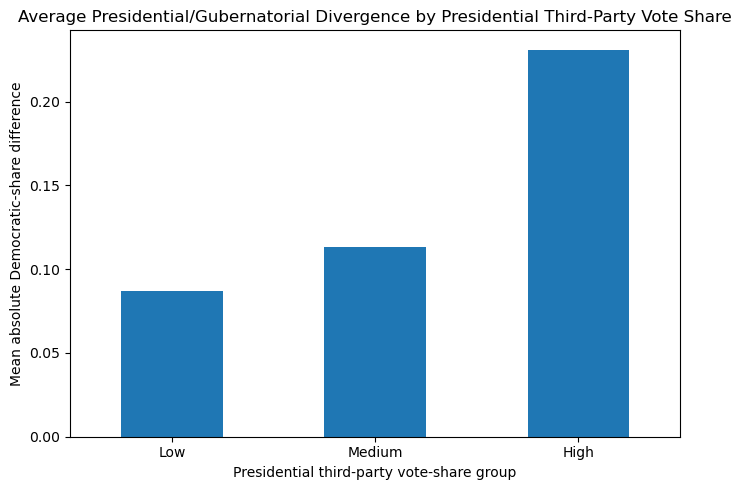

In [44]:
#plot grouped divergence by third-party bin

third_party_summary['mean'].plot(kind='bar', figsize=(7, 5))
plt.title('Average Presidential/Gubernatorial Divergence by Presidential Third-Party Vote Share')
plt.xlabel('Presidential third-party vote-share group')
plt.ylabel('Mean absolute Democratic-share difference')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Result 4. Which counties are the largest outliers?


Ranking counties by absolute Democratic-share difference between the two offices, all ten of the largest outliers are in Vermont or New Hampshire, and all ten involve a winner change between offices. The single largest outlier is Dixville, New Hampshire, where every presidential vote cast went to the Democratic candidate (a two-party share of 1.00) while only 20% of gubernatorial two-party votes did, a 0.80 swing. The remaining nine outliers are all Vermont towns (Landgrove, Stowe, Waterbury, Shelburne, Fayston, Charlotte, Moretown, Woodstock, and Waitsfield), each with presidential Democratic shares above 0.80 but gubernatorial Democratic shares between 0.26 and 0.32, a pattern which implies Republican governor Phil Scott's unusual strength in otherwise heavily Democratic towns. The concentration of outliers in just two states reinforces the core finding from our earlier sections: cross-office ticket-splitting in 2020 was not a widespread phenomenon, but rather a localized one driven by specific state-level dynamics.

In [45]:
#top counties by divergence across offices

outlier_cols = [
    'state', 'county',
    'pres_dem_share_2party',
    'gov_dem_share_2party',
    'abs_dem_share_diff',
    'winner_mismatch'
]

largest_outliers = analysis_df[outlier_cols].sort_values('abs_dem_share_diff', ascending=False).head(10)
largest_outliers.round(3)


,state,county,pres_dem_share_2party,gov_dem_share_2party,abs_dem_share_diff,winner_mismatch
321,New Hampshire,Dixville,1.000,0.200,0.800,True
790,Vermont,Landgrove,0.864,0.267,0.597,True
876,Vermont,Stowe,0.817,0.263,0.554,True
901,Vermont,Waterbury,0.815,0.276,0.539,True
861,Vermont,Shelburne,0.819,0.280,0.539,True
755,Vermont,Fayston,0.840,0.311,0.529,True
727,Vermont,Charlotte,0.816,0.297,0.519,True
929,Vermont,Woodstock,0.801,0.287,0.514,True
894,Vermont,Waitsfield,0.836,0.322,0.514,True
811,Vermont,Moretown,0.801,0.289,0.512,True


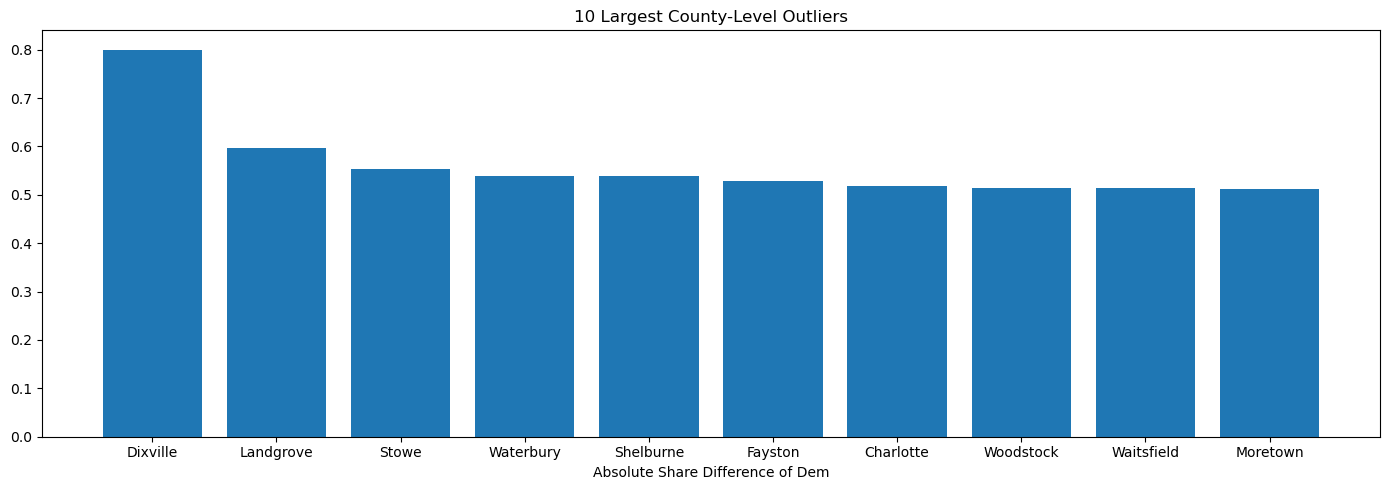

In [46]:
#Bar plot for Top 10 Outliers

x_labels = largest_outliers['county']
plt.figure(figsize=(14,5))
plt.bar(x_labels, largest_outliers['abs_dem_share_diff'])
plt.xlabel('Absolute Share Difference of Dem')
plt.title("10 Largest County-Level Outliers")
plt.tight_layout()

plt.show()

## Discussion

Our analysis shows that across the eleven states holding both a presidential and a gubernatorial race in 2020, county-level results for the two offices were very tightly aligned on average, but that the average hides two very different regimes. In nine of the eleven states, correlations between presidential and gubernatorial Democratic vote share exceeded 0.95 and mean absolute differences stayed below 0.05, producing essentially no county-level winner mismatches. Vermont and New Hampshire, however, showed large and systematic divergence driven by unusually popular Republican governors (Phil Scott and Chris Sununu) running in states that Biden decisively won. These two states account for nearly every mismatched county in the dataset and all ten of the largest outliers. The third-party hypothesis also received modest support: divergence between the two offices rose noticeably in the top third of counties by presidential third-party vote share, though this effect is partially entangled with the Vermont/New Hampshire pattern. Overall, we read the data as suggesting that 2020 voter behavior was highly "nationalized" in most of the states we studied. Voters broadly treated the presidential and gubernatorial choices as the same partisan question, with the important exception of a few states where strong incumbent personalities still pulled large numbers of voters across party lines. Key limitations include the aforementioned town-level reporting in Vermont and New Hampshire, which inflates their row counts relative to their actual county counts, and the small number of states available for a 2020-only analysis (only eleven states held both a presidential and a gubernatorial race that year, which limits how well our findings can be generalized). A worthwhile follow-up could examine whether the turnout gap itself predicts cross-office divergence: if counties where voters skip the down-ballot race more often also show larger share differences between offices, that would strengthen the interpretation of ticket-splitting as driven by voter-level rather than purely structural factors.